# Загрузка данных

Это моё решение задачи Toxic Comment Classification Challenge на Kaggle. В работе проводится анализ датасета и реализуется несколько моделей для multilabel-классификации токсичных комментариев, начиная с базовых методов и заканчивая дообучением трансформера DistilBERT.

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from datasets import Dataset as HFDataset

from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns



In [6]:
test = pd.read_csv('test.csv')
train = pd.read_csv('train.csv')
sample = pd.read_csv('sample_submission.csv')

In [16]:
labels = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']

In [14]:
import pandas as pd

pd.set_option('display.max_colwidth', None)

# EDA

In [15]:
train.head(10)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27",0,0,0,0,0,0
1,000103f0d9cfb60f,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info.",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on references or want to do it yourself please let me know.\n\nThere appears to be a backlog on articles for review so I guess there may be a delay until a reviewer turns up. It's listed in the relevant form eg Wikipedia:Good_article_nominations#Transport """,0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember what page that's on?",0,0,0,0,0,0
5,00025465d4725e87,"""\n\nCongratulations from me as well, use the tools well. · talk """,0,0,0,0,0,0
6,0002bcb3da6cb337,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1,1,1,0,1,0
7,00031b1e95af7921,"Your vandalism to the Matt Shirvington article has been reverted. Please don't do it again, or you will be banned.",0,0,0,0,0,0
8,00037261f536c51d,"Sorry if the word 'nonsense' was offensive to you. Anyway, I'm not intending to write anything in the article(wow they would jump on me for vandalism), I'm merely requesting that it be more encyclopedic so one can use it for school as a reference. I have been to the selective breeding page but it's almost a stub. It points to 'animal breeding' which is a short messy article that gives you no info. There must be someone around with expertise in eugenics? 93.161.107.169",0,0,0,0,0,0
9,00040093b2687caa,alignment on this subject and which are contrary to those of DuLithgow,0,0,0,0,0,0


In [ ]:
train.isna().sum()

,0
id,0
comment_text,0
toxic,0
severe_toxic,0
obscene,0
threat,0
insult,0
identity_hate,0


In [ ]:
(train['comment_text'].str.strip() == "").sum()

np.int64(0)

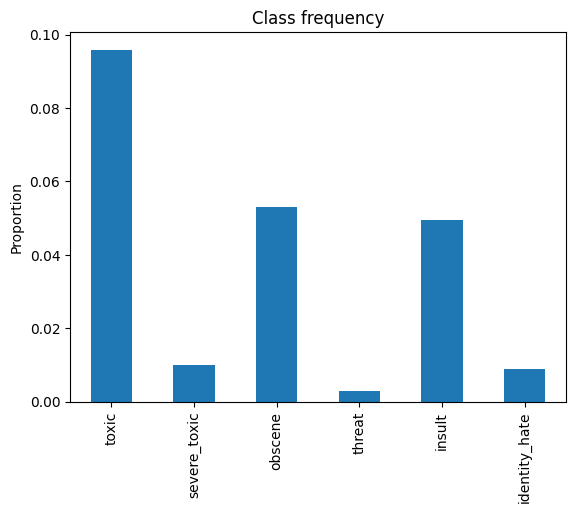

In [ ]:

labels = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']
train[labels].mean().plot(kind='bar')
plt.title("Class frequency")
plt.ylabel("Proportion")
plt.show()

Заметим сильный дисбаланс классов - используем стратифицированный отбор

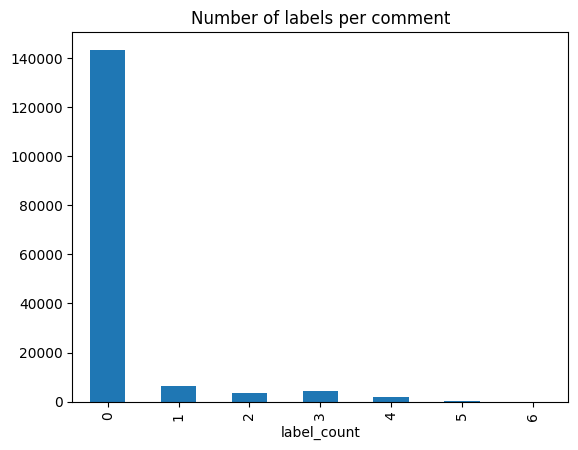

In [ ]:
train['label_count'] = train[labels].sum(axis=1)

train['label_count'].value_counts().sort_index().plot(kind='bar')
plt.title("Number of labels per comment")
plt.show()

Одному комменту может принадлежать несколько классов.

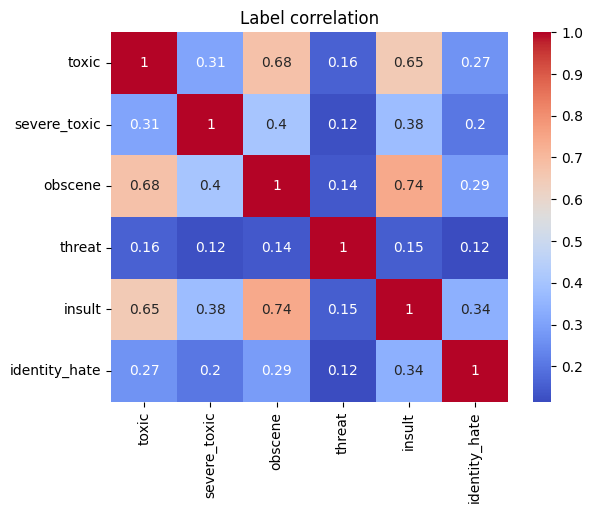

In [ ]:
import seaborn as sns

corr = train[labels].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Label correlation")
plt.show()

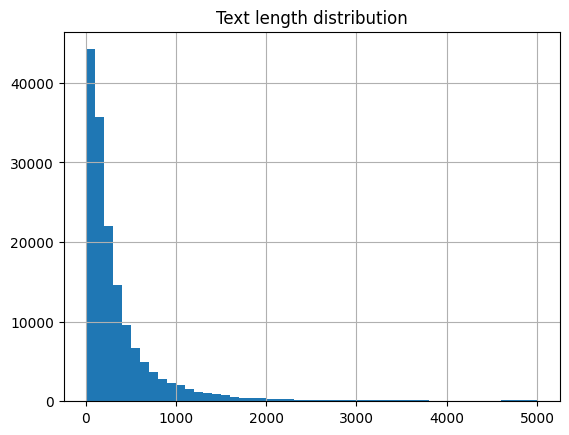

In [ ]:
train['text_length'] = train['comment_text'].str.len()

train['text_length'].hist(bins=50)
plt.title("Text length distribution")
plt.show()

Есть тяжёлый хвост по длине текста. Возможно придётся обрезать по max_length, проверим это на бейзлайне.

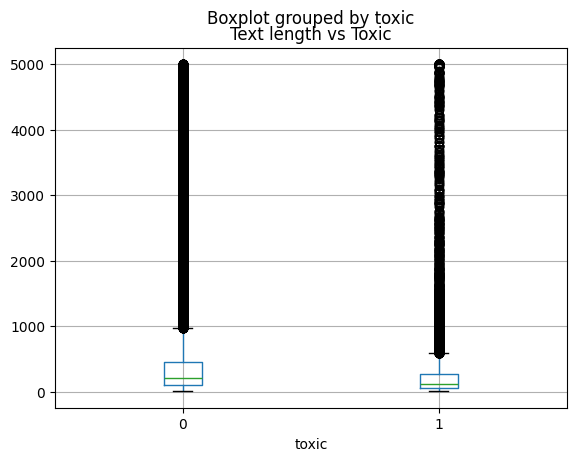

In [ ]:
train.boxplot(column='text_length', by='toxic')
plt.title("Text length vs Toxic")
plt.show()

In [ ]:
(train[labels].sum(axis=1) == 0).mean()

np.float64(0.8983211235124177)

Особо никакого feature engineering тут не проведёшь, так как классы убирать или склеивать нельзя, а с текстом мы и так определились

In [8]:
pip install iterative-stratification

In [17]:
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

X = train['comment_text'].fillna("")
y = train[labels].values

msss = MultilabelStratifiedShuffleSplit(
    n_splits=1, test_size=0.1, random_state=42
)

train_idx, val_idx = next(msss.split(X, y))

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = train.iloc[train_idx][labels], train.iloc[val_idx][labels]

# Baseline - LogReg

In [ ]:


model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features = 100000,
        ngram_range=(1,2),
        min_df=3,
        sublinear_tf = True
    )),
    ("clf", OneVsRestClassifier(
        LogisticRegression(
            C= 5,
            class_weight="balanced",
            max_iter=2000
        )
    ))

])
model.fit(X_train, y_train)



In [ ]:
y_proba = model.predict_proba(X_val)

pr_auc = average_precision_score(
    y_val,
    y_proba,
    average="macro"
)

print("PR-AUC macro:", pr_auc)

In [ ]:
print("train freq:\n", y_train.mean().round(4))
print("val   freq:\n", y_val.mean().round(4))

In [ ]:
from sklearn.metrics import average_precision_score

per_label_ap = {
    lab: average_precision_score(y_val[lab], y_proba[:, i])
    for i, lab in enumerate(labels)
}
print(per_label_ap)
print("macro:", np.mean(list(per_label_ap.values())))

Изменение параметров особо не помогло, видимо ~0,66 - это максимум для данной модели.

Также я заметил, что слабая регуляризация работает здесь несколько лучше

#  SVM

In [ ]:
from sklearn.linear_model import SGDClassifier

svm_sgd = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=100000, ngram_range=(1,2), min_df=3, sublinear_tf=True)),
    ("clf", OneVsRestClassifier(SGDClassifier(
        loss="hinge",
        alpha=1e-5,
        class_weight="balanced",
        max_iter=2000,
        tol=1e-3
    )))
])

svm_sgd.fit(X_train, y_train)
scores = svm_sgd.decision_function(X_val)
print("PR-AUC macro:", average_precision_score(y_val, scores, average="macro"))

PR-AUC macro: 0.6367613115397565


Попытка в LinearSVC оказалась проблемной: обучение долгое (особенно с калибровкой) и чувствительно к сходимости/гиперпараметрам; при некоторых настройках качество падало.

LinearSVC показал результат около 0.5, так что я заменил его на SGD

Попробуем обучить нейросеть, чтобы получить ощутимый прирост к скору

# Transformer

In [24]:
pip install iterative-stratification

In [22]:
pip install transformers datasets accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.4 MB/s eta 0:00:00


Так как мощности колаба не вывезли целого дня экспериментов с трансформерами, мне пришлось обучить его локально следующим кодом и выгрузить веса сюда

## Первая модель

Сразу оговорюсь, что коды от моделей вполне самостоятельные и чтобы их проверить, остальные ячейки запускать не нужно

In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import average_precision_score

# pip install iterative-stratification
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

from transformers import AutoTokenizer, AutoModelForSequenceClassification


SEED = 42
TRAIN_CSV = r"train.csv"
TEXT_COL = "comment_text"

LABELS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 256

BATCH_SIZE_TRAIN = 16
BATCH_SIZE_VAL = 32

LR = 2e-5
EPOCHS = 3

GRAD_ACCUM = 2          # эффективный batch = BATCH_SIZE_TRAIN * GRAD_ACCUM
WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0     # градиент-клиппинг (полезно)

PATIENCE = 2
MIN_DELTA = 1e-4

SAVE_DIR = "ckpt_distilbert_toxic"


def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


df = pd.read_csv(TRAIN_CSV)
df[TEXT_COL] = df[TEXT_COL].fillna("")

X = df[TEXT_COL].astype(str)
Y = df[LABELS].values.astype(np.int64)

print("rows:", len(df))
print("label rates:", df[LABELS].mean().round(4).to_dict())


msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=SEED)
tr_idx, va_idx = next(msss.split(X, Y))

X_train = X.iloc[tr_idx].tolist()
X_val = X.iloc[va_idx].tolist()
y_train = Y[tr_idx]
y_val = Y[va_idx]

print("train:", len(X_train), "val:", len(X_val))
print("val label rates:", pd.DataFrame(y_val, columns=LABELS).mean().round(4).to_dict())


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_texts(texts):
    return tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )

X_train_tok = tokenize_texts(X_train)
X_val_tok = tokenize_texts(X_val)


class ToxicDataset(Dataset):
    def __init__(self, encodings, labels):
        self.enc = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.enc["input_ids"][idx], dtype=torch.long),
            "attention_mask": torch.tensor(self.enc["attention_mask"][idx], dtype=torch.long),
            # multi-label => float targets (0/1)
            "labels": torch.tensor(self.labels[idx], dtype=torch.float32),
        }

train_ds = ToxicDataset(X_train_tok, y_train)
val_ds = ToxicDataset(X_val_tok, y_val)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE_TRAIN, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE_VAL, shuffle=False, num_workers=0)


model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABELS),
    problem_type="multi_label_classification",
)
model.to(device)


# -----------------------
# 7) METRIC: PR-AUC macro
# -----------------------
@torch.no_grad()
def eval_pr_auc(model, loader):
    model.eval()
    all_logits, all_y = [], []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        y = batch["labels"].cpu().numpy()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits.detach().cpu().numpy()

        all_logits.append(logits)
        all_y.append(y)

    logits = np.vstack(all_logits)
    ytrue = np.vstack(all_y)

    probs = 1 / (1 + np.exp(-logits))  # sigmoid
    return average_precision_score(ytrue, probs, average="macro")


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

use_amp = (device == "cuda")
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


best = -1.0
bad = 0

os.makedirs(SAVE_DIR, exist_ok=True)

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"epoch {epoch+1}/{EPOCHS}")
    optimizer.zero_grad()

    for step, batch in pbar:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels_t = batch["labels"].to(device)

        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels_t
            )
            loss = outputs.loss / GRAD_ACCUM

        scaler.scale(loss).backward()
        total_loss += loss.item() * GRAD_ACCUM

        if (step + 1) % GRAD_ACCUM == 0:
            # gradient clipping (после unscale)
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)

            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        if (step + 1) % 200 == 0:
            pbar.set_postfix(train_loss=total_loss / (step + 1))

    train_loss = total_loss / len(train_loader)
    val_score = eval_pr_auc(model, val_loader)

    print(f"\nepoch {epoch+1}: train_loss={train_loss:.4f}, val PR-AUC macro={val_score:.4f}\n")

    # early stopping + save best
    if val_score > best + MIN_DELTA:
        best = val_score
        bad = 0

        # сохраняем в huggingface формате
        model.save_pretrained(SAVE_DIR)
        tokenizer.save_pretrained(SAVE_DIR)

        meta = {
            "labels": LABELS,
            "max_len": MAX_LEN,
            "model_name": MODEL_NAME,
            "best_val_pr_auc_macro": float(best),
            "seed": SEED
        }
        with open(os.path.join(SAVE_DIR, "meta.json"), "w", encoding="utf-8") as f:
            json.dump(meta, f, ensure_ascii=False, indent=2)

        print("saved best to:", SAVE_DIR)
    else:
        bad += 1
        if bad >= PATIENCE:
            print("early stop")
            break

print("BEST val PR-AUC macro:", best)


@torch.no_grad()
def predict_proba(texts, batch_size=32):
    model.eval()
    all_probs = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(
            batch,
            padding="max_length",
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        logits = model(**enc).logits
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)

    return np.vstack(all_probs)

examples = [
    "You are an idiot and I hate you.",
    "Thanks for the helpful explanation!",
    "I will kill you."
]
p = predict_proba(examples)

for text, row in zip(examples, p):
    print("\nTEXT:", text)
    for lab, val in zip(LABELS, row):
        print(f"{lab:12s} {val:.3f}")

ModuleNotFoundError: No module named 'iterstrat'

In [31]:
!unzip ckpt_distilbert_toxic.zip

Archive:  ckpt_distilbert_toxic.zip
replace ckpt_distilbert_toxic/config.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

KeyboardInterrupt: 

In [32]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

PATH = "ckpt_distilbert_toxic"

tokenizer = AutoTokenizer.from_pretrained(PATH)
model = AutoModelForSequenceClassification.from_pretrained(PATH)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print("model loaded")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

model loaded


In [33]:
text = "You are stupid"

inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    padding=True
).to(device)

with torch.no_grad():
    logits = model(**inputs).logits
    probs = torch.sigmoid(logits)

print(probs)

tensor([[0.9933, 0.0349, 0.7246, 0.0019, 0.9134, 0.0055]], device='cuda:0')


In [34]:
import numpy as np
from sklearn.metrics import average_precision_score

def predict_proba(texts, batch_size=32):
    model.eval()
    all_probs = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(
            batch,
            padding="max_length",
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        with torch.no_grad():
            logits = model(**enc).logits
            probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.append(probs)

    return np.vstack(all_probs)

val_probs = predict_proba(X_val, batch_size=32)
val_pr_auc = average_precision_score(y_val, val_probs, average="macro")

print("Validation PR-AUC macro:", val_pr_auc)

Validation PR-AUC macro: 0.7149417441817656


In [37]:
from sklearn.metrics import roc_auc_score

roc = roc_auc_score(y_val, val_probs, average="macro")
print("ROC-AUC:", roc)

ROC-AUC: 0.9903354565008007


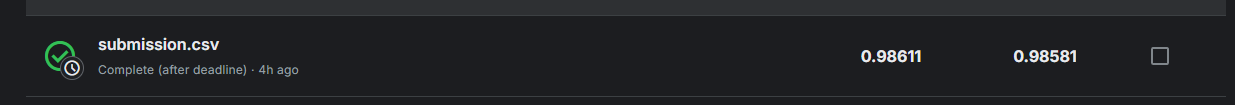

Неплохая попытка, на уровне 50% лучших в соревновании. Попробуем улучшить модель

In [43]:
from sklearn.metrics import average_precision_score

per_label_ap = {
    lab: average_precision_score(y_val[:, i], val_probs[:, i])
    for i, lab in enumerate(labels)
}

print(per_label_ap)
print("macro:", np.mean(list(per_label_ap.values())))

{'toxic': np.float64(0.9270232666955324), 'severe_toxic': np.float64(0.5344295775981218), 'obscene': np.float64(0.920887767428679), 'threat': np.float64(0.5015451417031919), 'insult': np.float64(0.8432688253818795), 'identity_hate': np.float64(0.5624958862831897)}
macro: 0.7149417441817656


## Вторая модель

Во второй версии модели был улучшен тренировочный пайплайн. Был добавлен learning rate scheduler с warmup, реализован gradient accumulation для увеличения эффективного размера батча и использовано mixed precision обучение (AMP) для ускорения работы на GPU. Также была добавлена ранняя остановка (early stopping) с сохранением лучшего чекпоинта по метрике macro PR-AUC.

In [ ]:
import os
import json
import math
import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import average_precision_score
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)


SEED = 42
TRAIN_CSV = "train.csv"
TEXT_COL = "comment_text"

LABELS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 256

BATCH_SIZE_TRAIN = 16
BATCH_SIZE_VAL = 32

LR = 2e-5
EPOCHS = 5

GRAD_ACCUM = 2               # эффективный batch = BATCH_SIZE_TRAIN * GRAD_ACCUM
WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0

PATIENCE = 2
MIN_DELTA = 1e-4

SAVE_DIR = "ckpt_distilbert_toxic"

# pos_weight:
# 1.0 = выключено
# "sqrt" = мягкое усиление редких классов (рекомендую начать с этого)
# "raw" = neg/pos без смягчения (обычно слишком агрессивно)
POS_WEIGHT_MODE = "sqrt"


def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # для воспроизводимости; может немного замедлить обучение
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


df = pd.read_csv(TRAIN_CSV)
df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str)

X = df[TEXT_COL]
Y = df[LABELS].values.astype(np.float32)

print("rows:", len(df))
print("label rates:", df[LABELS].mean().round(4).to_dict())


msss = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.1,
    random_state=SEED
)

tr_idx, va_idx = next(msss.split(X, Y))

X_train = X.iloc[tr_idx].tolist()
X_val = X.iloc[va_idx].tolist()
y_train = Y[tr_idx]
y_val = Y[va_idx]

print("train:", len(X_train), "val:", len(X_val))
print("val label rates:", pd.DataFrame(y_val, columns=LABELS).mean().round(4).to_dict())


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize_texts(texts):
    return tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )


print("tokenizing train...")
X_train_tok = tokenize_texts(X_train)

print("tokenizing val...")
X_val_tok = tokenize_texts(X_val)


class ToxicDataset(Dataset):
    def __init__(self, encodings, labels):
        self.enc = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.enc["input_ids"][idx], dtype=torch.long),
            "attention_mask": torch.tensor(self.enc["attention_mask"][idx], dtype=torch.long),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float32),
        }


train_ds = ToxicDataset(X_train_tok, y_train)
val_ds = ToxicDataset(X_val_tok, y_val)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE_TRAIN,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE_VAL,
    shuffle=False,
    num_workers=0
)


model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABELS)
)
model.to(device)


def build_pos_weight(y_train_np: np.ndarray, mode: str = "sqrt") -> torch.Tensor:
    """
    pos_weight_i = N_neg_i / N_pos_i

    Это усиливает штраф за ошибки на положительных примерах редких классов.
    Для очень редких классов raw-веса могут быть слишком большими,
    поэтому полезно взять sqrt(pos_weight) как более мягкий вариант.
    """
    pos_counts = y_train_np.sum(axis=0)                # сколько положительных по каждому классу
    neg_counts = len(y_train_np) - pos_counts          # сколько отрицательных

    raw_pos_weight = neg_counts / np.maximum(pos_counts, 1.0)

    if mode == "sqrt":
        final_pos_weight = np.sqrt(raw_pos_weight)
    elif mode == "raw":
        final_pos_weight = raw_pos_weight
    elif mode == "none":
        final_pos_weight = np.ones_like(raw_pos_weight)
    else:
        raise ValueError(f"Unknown POS_WEIGHT_MODE: {mode}")

    return torch.tensor(final_pos_weight, dtype=torch.float32)


pos_weight = build_pos_weight(y_train, mode=POS_WEIGHT_MODE).to(device)

print("pos_weight mode:", POS_WEIGHT_MODE)
print("pos_weight:")
for lab, w in zip(LABELS, pos_weight.detach().cpu().numpy()):
    print(f"  {lab:12s} {w:.4f}")

# Свой BCE loss с весами по классам
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


@torch.no_grad()
def collect_logits_and_targets(model, loader):
    model.eval()

    all_logits = []
    all_y = []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels_t = batch["labels"].cpu().numpy()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        logits = outputs.logits.detach().cpu().numpy()

        all_logits.append(logits)
        all_y.append(labels_t)

    logits = np.vstack(all_logits)
    ytrue = np.vstack(all_y)

    return logits, ytrue


@torch.no_grad()
def eval_pr_auc(model, loader, label_names):
    """
    Возвращает:
    - macro PR-AUC
    - per-label AP
    - вероятности
    - истинные метки
    """
    logits, ytrue = collect_logits_and_targets(model, loader)
    probs = 1.0 / (1.0 + np.exp(-logits))   # sigmoid

    per_label_ap = {
        lab: average_precision_score(ytrue[:, i], probs[:, i])
        for i, lab in enumerate(label_names)
    }

    macro_ap = float(np.mean(list(per_label_ap.values())))
    return macro_ap, per_label_ap, probs, ytrue


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

num_update_steps_per_epoch = math.ceil(len(train_loader) / GRAD_ACCUM)
num_training_steps = EPOCHS * num_update_steps_per_epoch
num_warmup_steps = int(0.1 * num_training_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

use_amp = (device == "cuda")
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

print("num_update_steps_per_epoch:", num_update_steps_per_epoch)
print("num_training_steps:", num_training_steps)
print("num_warmup_steps:", num_warmup_steps)


best = -1.0
bad = 0

os.makedirs(SAVE_DIR, exist_ok=True)

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    pbar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f"epoch {epoch+1}/{EPOCHS}"
    )

    optimizer.zero_grad()

    for step, batch in pbar:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels_t = batch["labels"].to(device)

        # autocast ускоряет обучение на GPU
        with torch.amp.autocast("cuda", enabled=use_amp):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits

            # Считаем BCE вручную
            loss = criterion(logits, labels_t)

            # При gradient accumulation делим loss,
            # чтобы итоговый градиент соответствовал большему batch size.
            loss = loss / GRAD_ACCUM

        scaler.scale(loss).backward()

        # Для красивого логирования возвращаем loss в исходный масштаб
        total_loss += loss.item() * GRAD_ACCUM

        # Делаем optimizer step:
        # 1) каждые GRAD_ACCUM шагов
        # 2) или на последнем batch, чтобы не потерять хвост эпохи
        do_step = ((step + 1) % GRAD_ACCUM == 0) or ((step + 1) == len(train_loader))

        if do_step:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)

            scaler.step(optimizer)
            scheduler.step()
            scaler.update()
            optimizer.zero_grad()

        if (step + 1) % 200 == 0:
            current_lr = scheduler.get_last_lr()[0]
            pbar.set_postfix(
                train_loss=total_loss / (step + 1),
                lr=f"{current_lr:.2e}"
            )

    train_loss = total_loss / len(train_loader)

    val_macro_ap, val_per_label_ap, _, _ = eval_pr_auc(model, val_loader, LABELS)

    print(f"\nepoch {epoch+1}: train_loss={train_loss:.4f}, val PR-AUC macro={val_macro_ap:.4f}")

    print("per-label AP:")
    for lab in LABELS:
        print(f"  {lab:12s} {val_per_label_ap[lab]:.4f}")
    print()

    # early stopping + save best
    if val_macro_ap > best + MIN_DELTA:
        best = val_macro_ap
        bad = 0

        model.save_pretrained(SAVE_DIR)
        tokenizer.save_pretrained(SAVE_DIR)

        meta = {
            "labels": LABELS,
            "max_len": MAX_LEN,
            "model_name": MODEL_NAME,
            "best_val_pr_auc_macro": float(best),
            "seed": SEED,
            "epochs": EPOCHS,
            "lr": LR,
            "weight_decay": WEIGHT_DECAY,
            "grad_accum": GRAD_ACCUM,
            "pos_weight_mode": POS_WEIGHT_MODE,
            "pos_weight": {lab: float(w) for lab, w in zip(LABELS, pos_weight.detach().cpu().numpy())},
            "per_label_ap": {lab: float(val_per_label_ap[lab]) for lab in LABELS}
        }

        with open(os.path.join(SAVE_DIR, "meta.json"), "w", encoding="utf-8") as f:
            json.dump(meta, f, ensure_ascii=False, indent=2)

        print("saved best to:", SAVE_DIR)

    else:
        bad += 1
        if bad >= PATIENCE:
            print("early stop")
            break

print("BEST val PR-AUC macro:", best)


# Чтобы инференс в конце шёл именно лучшей моделью, а не последней эпохой.
tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)
model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR).to(device)
model.eval()

print("best model reloaded from:", SAVE_DIR)


@torch.no_grad()
def predict_proba(texts, batch_size=32):
    model.eval()
    all_probs = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        enc = tokenizer(
            batch,
            padding="max_length",
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        logits = model(**enc).logits
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)

    return np.vstack(all_probs)


examples = [
    "You are an idiot and I hate you.",
    "Thanks for the helpful explanation!",
    "I will kill you."
]

p = predict_proba(examples)

for text, row in zip(examples, p):
    print("\nTEXT:", text)
    for lab, val in zip(LABELS, row):
        print(f"{lab:12s} {val:.3f}")

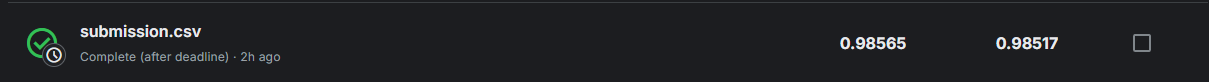

Чтобы понять причину ухудшения результата, были проанализированы значения PR-AUC по каждому классу. Сравнение показало, что после добавления pos_weight часть редких классов действительно улучшилась, однако качество на более частых метках ухудшилось, что в сумме снизило итоговый macro PR-AUC.

| Класс         | Первая версия | Вторая версия |
| ------------- | ------------- | ------------- |
| toxic         | **0.9270**    | 0.9230        |
| severe_toxic  | 0.5344        | **0.5497**    |
| obscene       | **0.9209**    | 0.9208        |
| threat        | 0.5015        | **0.5124**    |
| insult        | **0.8433**    | 0.8343        |
| identity_hate | **0.5625**    | 0.5448        |


Можно заметить, что редкие классы (severe_toxic, threat) действительно немного выросли, однако более частые (toxic, insult, identity_hate) ухудшились. Поскольку итоговая метрика macro PR-AUC является средним значением по всем классам, эти потери перевесили полученный выигрыш, и общий результат не улучшился.


## Финальная модель


На основании этого я решил отказаться от использования pos_weight и вернуться к стандартной функции потерь BCEWithLogitsLoss, сохранив при этом остальные улучшения тренировочного пайплайна.

In [ ]:
import os
import json
import math
import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import average_precision_score
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)


SEED = 42
TRAIN_CSV = "train.csv"
TEXT_COL = "comment_text"

LABELS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 256

BATCH_SIZE_TRAIN = 16
BATCH_SIZE_VAL = 32

LR = 2e-5
EPOCHS = 5

GRAD_ACCUM = 2
WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0

PATIENCE = 2
MIN_DELTA = 1e-4

SAVE_DIR = "ckpt_distilbert_toxic_no_posweight"


def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


df = pd.read_csv(TRAIN_CSV)
df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str)

X = df[TEXT_COL]
Y = df[LABELS].values.astype(np.float32)

print("rows:", len(df))
print("label rates:", df[LABELS].mean().round(4).to_dict())


msss = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.1,
    random_state=SEED
)

tr_idx, va_idx = next(msss.split(X, Y))

X_train = X.iloc[tr_idx].tolist()
X_val = X.iloc[va_idx].tolist()
y_train = Y[tr_idx]
y_val = Y[va_idx]

print("train:", len(X_train), "val:", len(X_val))
print("val label rates:", pd.DataFrame(y_val, columns=LABELS).mean().round(4).to_dict())


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize_texts(texts):
    return tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )


print("tokenizing train...")
X_train_tok = tokenize_texts(X_train)

print("tokenizing val...")
X_val_tok = tokenize_texts(X_val)


class ToxicDataset(Dataset):
    def __init__(self, encodings, labels):
        self.enc = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.enc["input_ids"][idx], dtype=torch.long),
            "attention_mask": torch.tensor(self.enc["attention_mask"][idx], dtype=torch.long),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float32),
        }


train_ds = ToxicDataset(X_train_tok, y_train)
val_ds = ToxicDataset(X_val_tok, y_val)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE_TRAIN,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE_VAL,
    shuffle=False,
    num_workers=0
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABELS)
)
model.to(device)


# Обычный BCE без pos_weight
criterion = nn.BCEWithLogitsLoss()


@torch.no_grad()
def collect_logits_and_targets(model, loader):
    model.eval()

    all_logits = []
    all_y = []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels_t = batch["labels"].cpu().numpy()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        logits = outputs.logits.detach().cpu().numpy()

        all_logits.append(logits)
        all_y.append(labels_t)

    logits = np.vstack(all_logits)
    ytrue = np.vstack(all_y)

    return logits, ytrue


@torch.no_grad()
def eval_pr_auc(model, loader, label_names):
    logits, ytrue = collect_logits_and_targets(model, loader)
    probs = 1.0 / (1.0 + np.exp(-logits))

    per_label_ap = {
        lab: average_precision_score(ytrue[:, i], probs[:, i])
        for i, lab in enumerate(label_names)
    }

    macro_ap = float(np.mean(list(per_label_ap.values())))
    return macro_ap, per_label_ap, probs, ytrue


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

num_update_steps_per_epoch = math.ceil(len(train_loader) / GRAD_ACCUM)
num_training_steps = EPOCHS * num_update_steps_per_epoch
num_warmup_steps = int(0.1 * num_training_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

use_amp = (device == "cuda")
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

print("num_update_steps_per_epoch:", num_update_steps_per_epoch)
print("num_training_steps:", num_training_steps)
print("num_warmup_steps:", num_warmup_steps)


best = -1.0
bad = 0

os.makedirs(SAVE_DIR, exist_ok=True)

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    pbar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f"epoch {epoch+1}/{EPOCHS}"
    )

    optimizer.zero_grad()

    for step, batch in pbar:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels_t = batch["labels"].to(device)

        with torch.amp.autocast("cuda", enabled=use_amp):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            loss = criterion(logits, labels_t)
            loss = loss / GRAD_ACCUM

        scaler.scale(loss).backward()
        total_loss += loss.item() * GRAD_ACCUM

        do_step = ((step + 1) % GRAD_ACCUM == 0) or ((step + 1) == len(train_loader))

        if do_step:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)

            scaler.step(optimizer)
            scheduler.step()
            scaler.update()
            optimizer.zero_grad()

        if (step + 1) % 200 == 0:
            current_lr = scheduler.get_last_lr()[0]
            pbar.set_postfix(
                train_loss=total_loss / (step + 1),
                lr=f"{current_lr:.2e}"
            )

    train_loss = total_loss / len(train_loader)

    val_macro_ap, val_per_label_ap, _, _ = eval_pr_auc(model, val_loader, LABELS)

    print(f"\nepoch {epoch+1}: train_loss={train_loss:.4f}, val PR-AUC macro={val_macro_ap:.4f}")
    print("per-label AP:")
    for lab in LABELS:
        print(f"  {lab:12s} {val_per_label_ap[lab]:.4f}")
    print(f"current best: {best:.4f}\n")

    if val_macro_ap > best + MIN_DELTA:
        best = val_macro_ap
        bad = 0

        model.save_pretrained(SAVE_DIR)
        tokenizer.save_pretrained(SAVE_DIR)

        meta = {
            "labels": LABELS,
            "max_len": MAX_LEN,
            "model_name": MODEL_NAME,
            "best_val_pr_auc_macro": float(best),
            "seed": SEED,
            "epochs": EPOCHS,
            "lr": LR,
            "weight_decay": WEIGHT_DECAY,
            "grad_accum": GRAD_ACCUM,
            "loss": "BCEWithLogitsLoss",
            "per_label_ap": {lab: float(val_per_label_ap[lab]) for lab in LABELS}
        }

        with open(os.path.join(SAVE_DIR, "meta.json"), "w", encoding="utf-8") as f:
            json.dump(meta, f, ensure_ascii=False, indent=2)

        print("saved best to:", SAVE_DIR)

    else:
        bad += 1
        if bad >= PATIENCE:
            print("early stop")
            break

print("BEST val PR-AUC macro:", best)


tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)
model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR).to(device)
model.eval()

print("best model reloaded from:", SAVE_DIR)


@torch.no_grad()
def predict_proba(texts, batch_size=32):
    model.eval()
    all_probs = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        enc = tokenizer(
            batch,
            padding="max_length",
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        logits = model(**enc).logits
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)

    return np.vstack(all_probs)


examples = [
    "You are an idiot and I hate you.",
    "Thanks for the helpful explanation!",
    "I will kill you."
]

p = predict_proba(examples)

for text, row in zip(examples, p):
    print("\nTEXT:", text)
    for lab, val in zip(LABELS, row):
        print(f"{lab:12s} {val:.3f}")

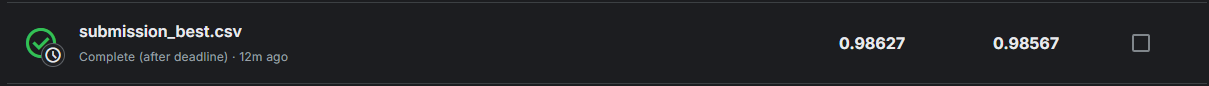

## Результаты всех моделей на PR_AUC

| Версия модели                               | Изменения                                    | PR-AUC macro |
| ------------------------------------------- | -------------------------------------------- | ------------ |
| **DistilBERT baseline**                     | стандартное fine-tuning                      | **0.71494**  |
| **DistilBERT + scheduler + pos_weight**     | добавлен scheduler и перевзвешивание классов | **0.71417**  |
| **DistilBERT + scheduler (без pos_weight)** | scheduler, gradient accumulation, AMP        | **0.71911**  |


Лучшая модель была получена примерно на третьей эпохе обучения и показала значение macro PR-AUC ~ 0.719 на валидационной выборке. После обучения была сформирована submission и отправлена на Kaggle для финальной оценки. По результатам нескольких отправок модель показала ROC-AUC около 0.985–0.986 на публичной части теста и до 0.98627 на приватной части, что подтверждает стабильность и хорошую обобщающую способность модели.

Таким образом, финальная версия представляет собой дообученный DistilBERT с оптимизированным тренировочным пайплайном и показывает высокое качество на задаче классификации токсичных комментариев.

## Submission maker

In [ ]:
import os
import json
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification


MODEL_DIR = "ckpt_distilbert_toxic_no_posweight"
TEST_CSV = "test.csv"
SAMPLE_SUB_CSV = "sample_submission.csv"
OUTPUT_CSV = "submission.csv"

TEXT_COL = "comment_text"
ID_COL = "id"

LABELS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

BATCH_SIZE_PRED = 32
DEFAULT_MAX_LEN = 256


device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


def load_meta(model_dir: str):
    meta_path = os.path.join(model_dir, "meta.json")
    if os.path.exists(meta_path):
        with open(meta_path, "r", encoding="utf-8") as f:
            meta = json.load(f)
        return meta
    return None


meta = load_meta(MODEL_DIR)

if meta is not None:
    max_len = meta.get("max_len", DEFAULT_MAX_LEN)
    labels_from_meta = meta.get("labels", LABELS)
    print("meta loaded:", meta)
else:
    max_len = DEFAULT_MAX_LEN
    labels_from_meta = LABELS
    print("meta.json not found, using default config")

# на всякий случай оставим итоговый порядок колонок фиксированным
LABELS = labels_from_meta


def load_model_and_tokenizer(model_dir: str, device: str):
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir)
    model.to(device)
    model.eval()
    return tokenizer, model


tokenizer, model = load_model_and_tokenizer(MODEL_DIR, device)
print("model loaded from:", MODEL_DIR)


def load_test_dataframe(test_csv: str):
    df = pd.read_csv(test_csv)
    if ID_COL not in df.columns:
        raise ValueError(f"В файле {test_csv} нет колонки '{ID_COL}'")
    if TEXT_COL not in df.columns:
        raise ValueError(f"В файле {test_csv} нет колонки '{TEXT_COL}'")

    df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str)
    return df


test_df = load_test_dataframe(TEST_CSV)
print("test shape:", test_df.shape)
print(test_df.head())


@torch.no_grad()
def predict_proba(
    texts,
    model,
    tokenizer,
    device,
    batch_size: int = 32,
    max_len: int = 256
):
    model.eval()
    all_probs = []

    for start in tqdm(range(0, len(texts), batch_size), desc="Predicting"):
        batch_texts = texts[start:start + batch_size]

        enc = tokenizer(
            batch_texts,
            padding="max_length",
            truncation=True,
            max_length=max_len,
            return_tensors="pt"
        )

        enc = {k: v.to(device) for k, v in enc.items()}

        logits = model(**enc).logits
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.append(probs)

    return np.vstack(all_probs)


test_texts = test_df[TEXT_COL].tolist()

test_probs = predict_proba(
    texts=test_texts,
    model=model,
    tokenizer=tokenizer,
    device=device,
    batch_size=BATCH_SIZE_PRED,
    max_len=max_len
)

print("test_probs shape:", test_probs.shape)


def build_submission(ids, probs, labels):
    if probs.shape[1] != len(labels):
        raise ValueError(
            f"Число столбцов в probs ({probs.shape[1]}) != числу labels ({len(labels)})"
        )

    sub = pd.DataFrame(probs, columns=labels)
    sub.insert(0, ID_COL, ids.values if hasattr(ids, "values") else ids)
    return sub


submission = build_submission(
    ids=test_df[ID_COL],
    probs=test_probs,
    labels=LABELS
)

print(submission.head())
print(submission.shape)


def validate_submission_format(submission_df: pd.DataFrame, sample_csv: str):
    if not os.path.exists(sample_csv):
        print(f"[warn] {sample_csv} not found, skip sample format check")
        return

    sample_df = pd.read_csv(sample_csv)

    print("sample shape:", sample_df.shape)

    if list(submission_df.columns) != list(sample_df.columns):
        raise ValueError(
            "Колонки submission не совпадают с sample_submission.\n"
            f"submission: {list(submission_df.columns)}\n"
            f"sample:     {list(sample_df.columns)}"
        )

    if len(submission_df) != len(sample_df):
        raise ValueError(
            f"Число строк submission ({len(submission_df)}) "
            f"не совпадает с sample_submission ({len(sample_df)})"
        )

    print("submission format is valid")


validate_submission_format(submission, SAMPLE_SUB_CSV)


submission.to_csv(OUTPUT_CSV, index=False)
print(f"submission saved to: {OUTPUT_CSV}")


print("\nSanity checks:")
print("min prob:", submission[LABELS].min().min())
print("max prob:", submission[LABELS].max().max())
print("mean probs by label:")
print(submission[LABELS].mean().round(6))


for i in range(min(3, len(test_df))):
    print("\nID:", test_df.iloc[i][ID_COL])
    print("TEXT:", test_df.iloc[i][TEXT_COL][:200].replace("\n", " "))
    for lab in LABELS:
        print(f"{lab:12s} {submission.iloc[i][lab]:.4f}")